# DistilBERT Gender Classifier

notebook adapted from: https://github.com/huggingface/notebooks/blob/main/examples/token_classification.ipynb

In [1]:
from collections import Counter, defaultdict
from transformers import AutoTokenizer, AutoModelForTokenClassification, DataCollatorForTokenClassification, Trainer, set_seed, TrainingArguments
import datasets
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import spacy
from spacy.tokens import Doc
from modules.evaluation import load_glitter, load_fairtranslate, load_gente, load_lexical, build_text_and_span, find_seed_token_index
import json
from datasets import Dataset, DatasetDict
import torch
from datasets import load_from_disk
from evaluate import load
import numpy as np
import sys

/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


sapienzanlp/maverick-mes-preco loading


Loading weights: 100%|█████████████████████| 390/390 [00:00<00:00, 43260.83it/s]
[transformers] DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-large
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/archite

In [2]:
nlp = spacy.load("en_core_web_md")
model_path = "./gender_bert"      
tokenizer_path = "./gender_bert"

In [3]:
task = "gender_det"
model_checkpoint = "distilbert-base-uncased"
model_checkpoint2 = "google-bert/bert-base-uncased"
batch_size = 16

In [4]:
train_files = [('../../data/glitter-splits/glitter-train.tsv', 'glitter'),
                ('../../data/gente-splits/gente-train.tsv', 'gente'),
                ('../../data/fairtranslate-splits/fairtranslate-train.tsv', 'fairtranslate'),
                ('../../data/lexical-splits/lexical-train.tsv', 'lexical')]

dev_files = [('../../data/glitter-splits/glitter-dev.tsv', 'glitter'),
                ('../../data/gente-splits/gente-dev.tsv', 'gente'),
                ('../../data/fairtranslate-splits/fairtranslate-dev.tsv', 'fairtranslate'),
                ('../../data/lexical-splits/lexical-dev.tsv', 'lexical')]

test_files = [('../../data/glitter-splits/glitter-test.tsv', 'glitter'),
                ('../../data/gente-splits/gente-test.tsv', 'gente'),
                ('../../data/fairtranslate-splits/fairtranslate-test.tsv', 'fairtranslate'),
                ('../../data/lexical-splits/lexical-test.tsv', 'lexical')]

## Preprocessing

In [5]:
def prepare_examples(filepath, dataset_type):
    """
    loads a dataset file and prepares each example for feature extraction.

    param filepath: path to the tsv file
    param dataset_type: one of 'glitter', 'gente', 'lexical', 'fairtranslate'

    returns a list of dicts
    """
    
    if dataset_type == 'glitter':
        og_examples = load_glitter(filepath)
    elif dataset_type == 'gente':
        og_examples = load_gente(filepath)
    elif dataset_type == 'lexical':
        og_examples = load_lexical(filepath)
    elif dataset_type == 'fairtranslate':
        og_examples = load_fairtranslate(filepath)
    else:
        raise ValueError('what is this dataset???' + dataset_type)

    prepared = []

    for example in og_examples:
        full_text, sentence_start_char, sentence_end_char = build_text_and_span(example, dataset_type)

        spacy_doc = nlp(full_text)

        seed_token_index = find_seed_token_index(spacy_doc, example['seed'], sentence_start_char, sentence_end_char)

        entry = {'text': full_text,
                'spacy_doc': spacy_doc,
                'seed_token_index': seed_token_index,
                'seed': example['seed'],
                'label': example['label'],
                'dataset_type': dataset_type,
                'prev_context': example.get('prev_context', ''),
                'next_context': example.get('next_context', '')}

        if 'stereotype' in example:
            entry['stereotype'] = example['stereotype']

        prepared.append(entry)

    return prepared

In [6]:
train_rows = list()
for filepath, dataset_type in train_files:
    train_rows.extend(prepare_examples(filepath, dataset_type))

dev_rows = list()
for filepath, dataset_type in dev_files:
    dev_rows.extend(prepare_examples(filepath, dataset_type))

test_rows = list()
for filepath, dataset_type in test_files:
    test_rows.extend(prepare_examples(filepath, dataset_type))

#remove examples where the seed token could not be located
#train_rows = [ex for ex in train_rows if ex['seed_token_index'] is not None]
#dev_rows = [ex for ex in dev_rows if ex['seed_token_index'] is not None]
#test_rows = [ex for ex in test_rows if ex['seed_token_index'] is not None]

print('train:', len(train_rows))
print('dev:', len(dev_rows))
print('test:', len(test_rows))

train: 2754
dev: 637
test: 1595


In [7]:
print(repr(test_rows[762]['text'][:300]))
print()
print('seed:', test_rows[762]['seed'])
print('label:', test_rows[762]['label'])

'The nurse administered a treatment to a patient requiring regular care and who was set to return home the same evening. He also explained the treatment steps to the family.'

seed: nurse
label: unambiguous_male


In [8]:
labels = ['ambiguous', 'unambiguous_all', 'unambiguous_female', 'unambiguous_male']

print(labels)

num_labels = list()

for i, label in enumerate(labels):
    num_labels.append(i)

print()
print(num_labels) 

['ambiguous', 'unambiguous_all', 'unambiguous_female', 'unambiguous_male']

[0, 1, 2, 3]


In [9]:
print("Example from the prepared data (dev set)")
print()

example = dev_rows[5]

print(example)

Example from the prepared data (dev set)

{'text': 'Chefs like her have broken through the glass ceilings of the culinary world, showcasing their expertise in cuisines ranging from French to fusion.', 'spacy_doc': Chefs like her have broken through the glass ceilings of the culinary world, showcasing their expertise in cuisines ranging from French to fusion., 'seed_token_index': 0, 'seed': 'chefs', 'label': 'unambiguous_female', 'dataset_type': 'glitter', 'prev_context': 'Julia Child revolutionized American cooking and empowered many women to pursue culinary careers. Her TV appearances made cooking accessible and charming to households everywhere.', 'next_context': 'They continue to influence aspiring culinary artists of all genders worldwide.'}


## Augmentation + Data Dict Format

In [10]:
def data_dict(examples, outputfile):
    preprocess = list()
    cue_special_token = '[CUE]'
    for sent_id, example in enumerate(examples):
        spacy_doc = example['spacy_doc']
        seed_index = example['seed_token_index']
        tokens = list()
        prev_context = example['prev_context']
        if prev_context:
            prev_doc = nlp.tokenizer(prev_context)
            for token in prev_doc:
                tokens.append(token.text)
                
        for i, token in enumerate(spacy_doc):
            if i == seed_index:
                tokens.append(cue_special_token)
            tokens.append(token.text)
            
        next_context = example['next_context']
        
        if next_context:
            next_doc = nlp.tokenizer(next_context)
            for token in next_doc:
                tokens.append(token.text)
                
        preprocess.append({'id': str(sent_id), 'tokens': tokens, 'labels': example['label']})
        
    with open(outputfile, 'w') as f:
        json.dump(preprocess, f, indent=2)
    print(f"length: {len(preprocess)}; saved to {outputfile}")

In [11]:
data_dict(dev_rows, 'gender_datadict_dev.json')
data_dict(train_rows, 'gender_datadict_train.json')
data_dict(test_rows, 'gender_datadict_test.json')

length: 637; saved to gender_datadict_dev.json
length: 2754; saved to gender_datadict_train.json
length: 1595; saved to gender_datadict_test.json


In [12]:
with open('gender_datadict_train.json', 'r') as f:
    train_data = json.load(f)
with open('gender_datadict_dev.json', 'r') as f:
    dev_data = json.load(f)
with open('gender_datadict_test.json', 'r') as f:
    test_data = json.load(f)

#create Dataset objects
train_dataset = Dataset.from_list(train_data)
dev_dataset = Dataset.from_list(dev_data)
test_dataset = Dataset.from_list(test_data)

dataset = DatasetDict({'train': train_dataset, 'validation': dev_dataset, 'test': test_dataset})

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'labels'],
        num_rows: 2754
    })
    validation: Dataset({
        features: ['id', 'tokens', 'labels'],
        num_rows: 637
    })
    test: Dataset({
        features: ['id', 'tokens', 'labels'],
        num_rows: 1595
    })
})


### Examples (Augmentation)

In [13]:
print(dataset['train']['tokens'][20])
print()
print(dataset['train']['tokens'][21])
print()
print(dataset['train']['tokens'][22])

['The', 'bustling', 'construction', 'site', 'was', 'a', 'testament', 'to', 'the', 'city', "'s", 'growing', 'skyline', '.', 'Among', 'the', 'team', ',', 'Lee', 'was', 'respected', 'for', 'his', 'skills', 'and', 'leadership', '.', '[CUE]', 'Workers', 'coordinated', 'meticulously', ',', 'ensuring', 'that', 'the', 'project', 'stayed', 'on', 'track', 'and', 'met', 'safety', 'standards', '.', 'Their', 'collective', 'effort', 'was', 'pivotal', 'in', 'shaping', 'the', 'city', "'s", 'future', '.']

['At', 'the', 'same', 'time', ',', 'the', 'transition', 'to', 'a', 'qualitatively', 'new', 'modular', 'training', 'system', 'has', 'given', 'legal', 'education', 'a', 'completely', 'new', 'impulse', '.', 'The', 'teaching', 'staff', 'of', 'the', 'university', 'currently', 'more', 'than', '250', 'employees', ',', 'including', 'more', 'than', '20', 'doctors', 'of', 'science', ',', '60', 'doctors', 'of', 'philosophy', ',', '20', 'professors', ',', 'and', '30', 'associate', 'professors', '.', 'The', 'univ

In [14]:
dataset.save_to_disk('gender_dataset')

Saving the dataset (1/1 shards): 100%|█| 2754/2754 [00:00<00:00, 596833.38 examp
Saving the dataset (1/1 shards): 100%|█| 637/637 [00:00<00:00, 278948.80 example
Saving the dataset (1/1 shards): 100%|█| 1595/1595 [00:00<00:00, 691392.61 examp


### Statistics

In [15]:
def count_tokens(split):
    """
    param split: dataset (train, test, or dev)
    """
    count = 0
    for sent in dataset[split]['tokens']:
        for row in sent:
            if row != '[CUE]':   #does not count special cue tokens
                count += 1

    return count

In [16]:
print('STATISTICS (excluding cue-indicating tokens):')

print()
print('sentences train:', len(dataset['train']))
print('sentences test:', len(dataset['test']))
print('sentences dev:', len(dataset['validation']))
print()
print('tokens train:', count_tokens('train'))
print('tokens test:', count_tokens('test'))
print('tokens dev:', count_tokens('validation'))

STATISTICS (excluding cue-indicating tokens):

sentences train: 2754
sentences test: 1595
sentences dev: 637

tokens train: 107380
tokens test: 71670
tokens dev: 24029


### Loading Dataset

In [17]:
datasets = load_from_disk('gender_dataset')

In [18]:
datasets

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'labels'],
        num_rows: 2754
    })
    validation: Dataset({
        features: ['id', 'tokens', 'labels'],
        num_rows: 637
    })
    test: Dataset({
        features: ['id', 'tokens', 'labels'],
        num_rows: 1595
    })
})

In [19]:
print(datasets["train"][0])

{'id': '0', 'tokens': ['July', '2', ',', '2019', ',', 'Sproul', 'became', 'ordained', 'through', 'Logos', 'Ministries', 'of', 'Florida', 'and', 'formed', 'the', 'business', 'entity', 'Dunamis', 'Fellowship', '.', 'February', '14', ',', '2021', ',', 'Sproul', 'planted', 'his', 'newest', 'church', ',', 'Sovereign', 'Grace', 'Fellowship', 'in', 'Fort', 'Wayne', ',', 'Indiana', '.', 'Sproul', 'announced', 'April', '3', ',', '2021', ',', 'he', 'would', 'launch', 'the', 'Shepherd', '’s', 'College', ',', 'August', '30', ',', '2021', ',', 'as', 'a', '[CUE]', 'pastors', 'college', 'for', 'training', 'and', 'mentoring', 'men', 'nationally', 'and', 'internationally', '.', 'Publishing', 'Sproul', 'has', 'written', 'twelve', 'books', ',', 'including', 'When', 'You', 'Rise', 'Up', ':', 'A', 'Covenantal', 'Approach', 'to', 'Homeschooling', ',', 'Bound', 'for', 'Glory', ',', 'Biblical', 'Economics', ',', 'Almighty', 'Over', 'All', ',', 'Eternity', 'in', 'Our', 'Hearts', ',', 'and', 'Tearing', 'Down', 

In [20]:
label_list = labels
print(label_list)

['ambiguous', 'unambiguous_all', 'unambiguous_female', 'unambiguous_male']


## Preprocessing loaded dataset

In [21]:
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

num_added_toks = tokenizer.add_tokens('[CUE]', special_tokens=True)  #convert cue indicator to a special token

### Examples

#### Before Tokenizing

In [22]:
example = datasets["train"][0]
print(example["tokens"])

['July', '2', ',', '2019', ',', 'Sproul', 'became', 'ordained', 'through', 'Logos', 'Ministries', 'of', 'Florida', 'and', 'formed', 'the', 'business', 'entity', 'Dunamis', 'Fellowship', '.', 'February', '14', ',', '2021', ',', 'Sproul', 'planted', 'his', 'newest', 'church', ',', 'Sovereign', 'Grace', 'Fellowship', 'in', 'Fort', 'Wayne', ',', 'Indiana', '.', 'Sproul', 'announced', 'April', '3', ',', '2021', ',', 'he', 'would', 'launch', 'the', 'Shepherd', '’s', 'College', ',', 'August', '30', ',', '2021', ',', 'as', 'a', '[CUE]', 'pastors', 'college', 'for', 'training', 'and', 'mentoring', 'men', 'nationally', 'and', 'internationally', '.', 'Publishing', 'Sproul', 'has', 'written', 'twelve', 'books', ',', 'including', 'When', 'You', 'Rise', 'Up', ':', 'A', 'Covenantal', 'Approach', 'to', 'Homeschooling', ',', 'Bound', 'for', 'Glory', ',', 'Biblical', 'Economics', ',', 'Almighty', 'Over', 'All', ',', 'Eternity', 'in', 'Our', 'Hearts', ',', 'and', 'Tearing', 'Down', 'Strongholds', '.']


#### After Tokenizing

In [23]:
tokenized_input = tokenizer(example["tokens"], is_split_into_words=True, truncation=True)
tokens = tokenizer.convert_ids_to_tokens(tokenized_input["input_ids"])
print(tokens)
print()
print(tokenized_input)

['[CLS]', 'july', '2', ',', '2019', ',', 'sp', '##rou', '##l', 'became', 'ordained', 'through', 'logos', 'ministries', 'of', 'florida', 'and', 'formed', 'the', 'business', 'entity', 'dun', '##ami', '##s', 'fellowship', '.', 'february', '14', ',', '2021', ',', 'sp', '##rou', '##l', 'planted', 'his', 'newest', 'church', ',', 'sovereign', 'grace', 'fellowship', 'in', 'fort', 'wayne', ',', 'indiana', '.', 'sp', '##rou', '##l', 'announced', 'april', '3', ',', '2021', ',', 'he', 'would', 'launch', 'the', 'shepherd', '’', 's', 'college', ',', 'august', '30', ',', '2021', ',', 'as', 'a', '[CUE]', 'pastor', '##s', 'college', 'for', 'training', 'and', 'mentoring', 'men', 'nationally', 'and', 'internationally', '.', 'publishing', 'sp', '##rou', '##l', 'has', 'written', 'twelve', 'books', ',', 'including', 'when', 'you', 'rise', 'up', ':', 'a', 'covenant', '##al', 'approach', 'to', 'homes', '##cho', '##olin', '##g', ',', 'bound', 'for', 'glory', ',', 'biblical', 'economics', ',', 'almighty', 'over

In [24]:
label_all_tokens = True

In [25]:
def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(examples["tokens"], truncation=True, is_split_into_words=True)

    all_label_ids = []
    for i, label in enumerate(examples["labels"]):
        label_id = label_list.index(label)
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        tokens = examples["tokens"][i]
        label_ids = []
        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            elif tokens[word_idx] == '[CUE]':
                label_ids.append(label_id)
            else:
                label_ids.append(-100)
        all_label_ids.append(label_ids)

    tokenized_inputs["labels"] = all_label_ids
    return tokenized_inputs

In [26]:
tokenized_datasets = datasets.map(tokenize_and_align_labels, batched=True)

## Fine-Tuning the Model

In [27]:
model = AutoModelForTokenClassification.from_pretrained(model_checkpoint, num_labels=len(label_list))

model.resize_token_embeddings(len(tokenizer))

Loading weights: 100%|██████████████████████| 100/100 [00:00<00:00, 2956.40it/s]
[transformers] DistilBertForTokenClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Embedding(30523, 768, padding_idx=0)

In [28]:
from transformers import set_seed

#seed used here: 14

#seed used: 14, 45, 98

SEED = 14
set_seed(SEED)

model_name = model_checkpoint.split("/")[-1]
args = TrainingArguments(
    f"{model_name}-finetuned-{task}",
    eval_strategy = "epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    num_train_epochs=3,
    weight_decay=0.01,
    seed=SEED,
    report_to=[],
    logging_strategy = 'epoch'
)

In [29]:
data_collator = DataCollatorForTokenClassification(tokenizer)

In [30]:
metric = load("seqeval")

labels = label_list

print(labels)

['ambiguous', 'unambiguous_all', 'unambiguous_female', 'unambiguous_male']


In [31]:
def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    # Remove ignored index (special tokens)
    true_predictions = [
        [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    results = metric.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }

In [32]:
trainer = Trainer(
    model,
    args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

In [33]:
print(model.num_labels)

print(len(label_list))

print(label_list)

4
4
['ambiguous', 'unambiguous_all', 'unambiguous_female', 'unambiguous_male']


In [34]:
trainer.train()

/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.608071,0.329685,0.890110,0.890110,0.890110,0.890110
2,0.166666,0.238542,0.910518,0.910518,0.910518,0.910518
3,0.088747,0.228514,0.926217,0.926217,0.926217,0.926217


/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: ambiguous seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: unambiguous_female seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: unambiguous_all seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: unambiguous_male seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/seqeval/metrics/v

TrainOutput(global_step=519, training_loss=0.28782808711763064, metrics={'train_runtime': 2012.5094, 'train_samples_per_second': 4.105, 'train_steps_per_second': 0.258, 'total_flos': 288246472902048.0, 'train_loss': 0.28782808711763064, 'epoch': 3.0})

In [35]:
predictions, labels, _ = trainer.predict(tokenized_datasets["validation"])     #intermediate validation set results
predictions = np.argmax(predictions, axis=2)

# Remove ignored index (special tokens)
true_predictions = [
    [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
    for prediction, label in zip(predictions, labels)
]
true_labels = [
    [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
    for prediction, label in zip(predictions, labels)
]

In [36]:
trainer.save_model("./gender_bert")
tokenizer.save_pretrained("./gender_bert")

Writing model shards: 100%|███████████████████████| 1/1 [00:00<00:00,  4.24it/s]


('./gender_bert/tokenizer_config.json', './gender_bert/tokenizer.json')

## Final Postprocessing

In [37]:
def extract_word_level_predictions(trainer, tokenized_dataset, tokenizer, label_list, skip_tokens=None):
    """
    get word-level predictions from subword predictions using majority voting.

    param1 trainer: the trained model
    param2 tokenized_dataset: the dataset that will be predicted
    param3 tokenizer: turns tokens into IDs and back
    param4 label_list: maps label IDs to actual label names
    param5 skip_tokens: tokens that should not be included in the predictions
    """
    if skip_tokens == None:
        skip_tokens = []

    #get predictions
    predictions_output = trainer.predict(tokenized_dataset)
    raw_predictions = predictions_output.predictions
    predictions = np.argmax(raw_predictions, axis=2)

    all_word_tokens = []
    all_word_predictions = []

    #go through each example
    for idx in range(len(predictions)):
        example = tokenized_dataset[idx]

        #subtokens to original tokens
        tokenized_input = tokenizer(example['tokens'], is_split_into_words=True, truncation=True)
        word_ids = tokenized_input.word_ids()

        #group predictions by word
        word_to_preds = defaultdict(list)
        for token_idx, word_id in enumerate(word_ids):
            if word_id is not None:
                pred_label = predictions[idx][token_idx]
                word_to_preds[word_id].append(pred_label)

        #use majority vote for each word
        for word_id in sorted(word_to_preds.keys()):
            original_word = example['tokens'][word_id]

            #skip pred indication
            if original_word in skip_tokens:
                continue

            #pick most common prediction
            pred_counts = Counter(word_to_preds[word_id])
            most_common_pred = pred_counts.most_common(1)[0][0]

            all_word_tokens.append(original_word)
            all_word_predictions.append(label_list[most_common_pred])

    return all_word_tokens, all_word_predictionsPreprocessing

In [38]:
def extract_cue_predictions(trainer, tokenized_dataset, og_examples, tokenizer, label_list):
    """
    predicts a single gender label per example, based on a majority
    vote over the subtokens of the [CUE] token.

    param trainer: the trained model
    param tokenized_dataset: the tokenized dataset (containing [CUE] markers)
    param og_examples: the original prepared examples (same order), used for gold labels
    param tokenizer: turns tokens into IDs and back
    param label_list: maps label IDs to actual label names
    """
    predictions_output = trainer.predict(tokenized_dataset)
    raw_predictions = predictions_output.predictions
    predictions = np.argmax(raw_predictions, axis=2)

    all_predictions = list()
    all_gold = list()

    for idx in range(len(predictions)):
        example = tokenized_dataset[idx]

        tokenized_input = tokenizer(example['tokens'], is_split_into_words=True, truncation=True)
        word_ids = tokenized_input.word_ids()

        word_to_preds = defaultdict(list)
        for token_idx, word_id in enumerate(word_ids):
            if word_id is not None:
                pred_label = predictions[idx][token_idx]
                word_to_preds[word_id].append(pred_label)

        cue_word_id = None
        for word_id, token_text in enumerate(example['tokens']):
            if token_text == '[CUE]':
                cue_word_id = word_id
                break

        pred_counts = Counter(word_to_preds[cue_word_id])
        most_common_pred = pred_counts.most_common(1)[0][0]

        all_predictions.append(label_list[most_common_pred])
        all_gold.append(og_examples[idx]['label'])

    return all_predictions, all_gold

In [39]:
predictions_output = trainer.predict(tokenized_datasets["test"])
raw_predictions = predictions_output.predictions
predictions = np.argmax(raw_predictions, axis=2)

In [40]:
predictions, gold_labels = extract_cue_predictions(
    trainer=trainer,
    tokenized_dataset=tokenized_datasets["test"],
    og_examples=test_rows,
    tokenizer=tokenizer,
    label_list=label_list
)

print("Total predictions:", len(predictions))
print()
print("First 20 predictions:", predictions[:20])
print()
print("First 20 gold labels:", gold_labels[:20])

Total predictions: 1595

First 20 predictions: ['unambiguous_female', 'ambiguous', 'ambiguous', 'unambiguous_male', 'ambiguous', 'unambiguous_female', 'unambiguous_female', 'unambiguous_all', 'unambiguous_female', 'unambiguous_female', 'unambiguous_female', 'unambiguous_male', 'ambiguous', 'unambiguous_female', 'unambiguous_male', 'ambiguous', 'ambiguous', 'unambiguous_female', 'unambiguous_male', 'unambiguous_female']

First 20 gold labels: ['ambiguous', 'ambiguous', 'unambiguous_male', 'unambiguous_male', 'unambiguous_all', 'ambiguous', 'unambiguous_female', 'unambiguous_all', 'unambiguous_female', 'unambiguous_female', 'unambiguous_female', 'unambiguous_male', 'ambiguous', 'unambiguous_female', 'ambiguous', 'ambiguous', 'ambiguous', 'unambiguous_all', 'unambiguous_male', 'unambiguous_all']


In [41]:
print('lists should have the same length')
print(len(predictions))
print(len(gold_labels))
print(len(test_rows))

lists should have the same length
1595
1595
1595


## Final Evaluation

In [42]:
print(classification_report(gold_labels, predictions, labels=sorted(set(predictions).union(gold_labels)), digits=3))

                    precision    recall  f1-score   support

         ambiguous      0.924     0.929     0.926       651
   unambiguous_all      0.708     0.531     0.607        32
unambiguous_female      0.950     0.946     0.948       464
  unambiguous_male      0.921     0.933     0.927       448

          accuracy                          0.927      1595
         macro avg      0.876     0.835     0.852      1595
      weighted avg      0.926     0.927     0.926      1595



In [43]:
classification_dict = classification_report(gold_labels, predictions, labels=sorted(set(predictions).union(gold_labels)), digits=3, output_dict=True)

In [44]:
def evaluate_by_dataset(test_rows, predictions, gold_labels):
    """
    prints a classification report separately for each dataset_type present in test_rows.

    param test_rows: list of prepared examples (must include 'dataset_type')
    param predictions: list of predicted labels, same order as test_rows
    param gold_labels: list of gold labels, same order as test_rows
    """
    predictions_by_dataset = dict()
    gold_by_dataset = dict()

    for i, example in enumerate(test_rows):
        dataset_type = example['dataset_type']

        if dataset_type not in predictions_by_dataset:
            predictions_by_dataset[dataset_type] = list()
            gold_by_dataset[dataset_type] = list()

        predictions_by_dataset[dataset_type].append(predictions[i])
        gold_by_dataset[dataset_type].append(gold_labels[i])

    dataset_types = sorted(predictions_by_dataset.keys())

    for dataset_type in dataset_types:
        dataset_predictions = predictions_by_dataset[dataset_type]
        dataset_gold = gold_by_dataset[dataset_type]

        print(dataset_type)
        print('n =', len(dataset_gold))
        dataset_labels = sorted(set(dataset_predictions).union(dataset_gold))
        print(classification_report(dataset_gold, dataset_predictions, labels=dataset_labels, digits=3))
        print()


evaluate_by_dataset(test_rows, predictions, gold_labels)

fairtranslate
n = 540
                    precision    recall  f1-score   support

         ambiguous      1.000     0.996     0.998       259
unambiguous_female      0.993     1.000     0.996       139
  unambiguous_male      1.000     1.000     1.000       142

          accuracy                          0.998       540
         macro avg      0.998     0.999     0.998       540
      weighted avg      0.998     0.998     0.998       540


gente
n = 242
                    precision    recall  f1-score   support

         ambiguous      0.982     0.933     0.957        60
unambiguous_female      1.000     0.989     0.995        94
  unambiguous_male      0.957     1.000     0.978        88

          accuracy                          0.979       242
         macro avg      0.980     0.974     0.977       242
      weighted avg      0.980     0.979     0.979       242


glitter
n = 392
                    precision    recall  f1-score   support

         ambiguous      0.829     0.849

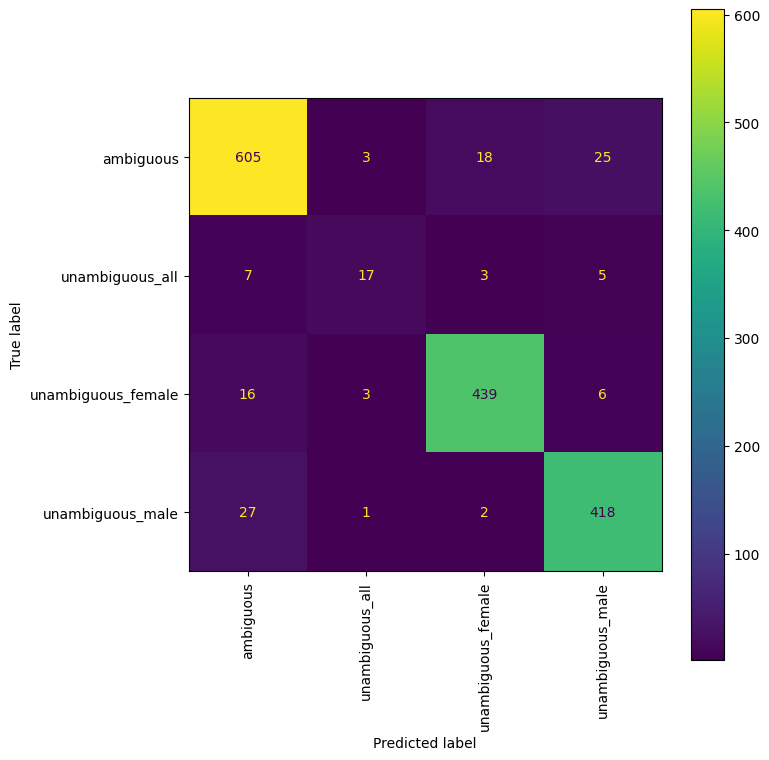

In [45]:
labels_cm = sorted(set(predictions).union(gold_labels))

cm = confusion_matrix(gold_labels, predictions, labels=labels_cm)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_cm)

disp.plot(ax=ax)

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [46]:
def write_results_to_tsv(examples, outfile_path, predictions, gold_labels):
    """
    writes results to a tsv file.
    format: seed, sentence, gold label, predicted label

    param examples: list of prepared examples
    param outfile_path: path to output file
    param predictions: list of predicted labels
    param gold_labels: list of gold labels
    """
    with open(outfile_path, 'w', encoding='utf8') as outfile:
        outfile.write('seed\tsentence\tgold\tprediction\n')
        for example, pred_label, gold_label in zip(examples, predictions, gold_labels):
            outfile.write(example['seed'] + '\t' + example['text'] + '\t' + gold_label + '\t' + pred_label + '\n')

In [47]:
write_results_to_tsv(test_rows, 'test_bert_results.tsv', predictions, gold_labels)

### Standalone Sentence Function

In [48]:
def sentence_to_pred(tokens, cue_index, trainer=trainer, tokenizer=tokenizer, label_list=label_list):
    """
    predicts the gender label for a noun in a sentence.

    param tokens: sentence as a list of word tokens
    param cue_index: index of the token whose gender should be classified
    param trainer: trainer of the used model
    param tokenizer: tokenizer
    param label_list: sorted list of unique labels
    """
    tokens_with_cue = list()
    for i, token in enumerate(tokens):
        if i == cue_index:
            tokens_with_cue.append('[CUE]')
        tokens_with_cue.append(token)

    example = {'id': '0', 'tokens': tokens_with_cue, 'labels': label_list[0]}

    temp_dataset = Dataset.from_list([example])

    tokenized = temp_dataset.map(tokenize_and_align_labels, batched=True)

    predictions, _ = extract_cue_predictions(trainer=trainer, tokenized_dataset=tokenized,
        og_examples=[{'label': None}],
        tokenizer=tokenizer,
        label_list=label_list)

    return predictions[0]

In [49]:
example_sentence = ['The', 'nurse', 'told', 'him', 'to', 'wait', 'outside', '.']
example_cue_index = 1

prediction = sentence_to_pred(example_sentence, example_cue_index)

print("Tokens:", example_sentence)
print("Cue token:", example_sentence[example_cue_index])
print("Predicted gender label:", prediction)

Map: 100%|█████████████████████████████████| 1/1 [00:00<00:00, 56.72 examples/s]
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: ambiguous seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: unambiguous_male seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zer

Tokens: ['The', 'nurse', 'told', 'him', 'to', 'wait', 'outside', '.']
Cue token: nurse
Predicted gender label: unambiguous_male


In [50]:
example_sentence = ['The', 'prince', 'was', 'tired', '.']
example_cue_index = 1

prediction = sentence_to_pred(example_sentence, example_cue_index)

print("Tokens:", example_sentence)
print("Cue token:", example_sentence[example_cue_index])
print("Predicted gender label:", prediction)

Map: 100%|████████████████████████████████| 1/1 [00:00<00:00, 329.87 examples/s]


Tokens: ['The', 'prince', 'was', 'tired', '.']
Cue token: prince
Predicted gender label: unambiguous_male


In [51]:
example_sentence = ['The', 'teacher', 'was', 'a', 'woman', 'who', 'was', 'tired', 'of', 'dogs', 'eating', 'homework', '.']
example_cue_index = 1

prediction = sentence_to_pred(example_sentence, example_cue_index)

print("Tokens:", example_sentence)
print("Cue token:", example_sentence[example_cue_index])
print("Predicted gender label:", prediction)

Map: 100%|████████████████████████████████| 1/1 [00:00<00:00, 377.56 examples/s]


/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: unambiguous_female seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))


Tokens: ['The', 'teacher', 'was', 'a', 'woman', 'who', 'was', 'tired', 'of', 'dogs', 'eating', 'homework', '.']
Cue token: teacher
Predicted gender label: unambiguous_female
